### Requerimientos

#### 1. Explicación conceptual: estructura y utilidad de una red convolutiva
En un documento PDF o DOCX, redacta una explicación clara sobre qué es una red neuronal convolutiva, sus principales capas (convolución, pooling, flatten, densa), su funcionamiento y aplicaciones prácticas. Incluye un esquema o diagrama. (2 puntos)
#### 2. Implementación del modelo CNN para reconocimiento de imágenes
*  Utilizando el dataset digitos_mnist_simple.csv, construye un modelo CNN con Keras para clasificar los dígitos del 0 al 9.
*  Debes procesar los datos (reshape, normalización), definir y entrenar el modelo, mostrar métricas como accuracy, loss, y la matriz de confusión. Incluye el código explicado.

#### 3. Evaluación y optimización del modelo
*  Describe y aplica al menos dos técnicas de mejora del desempeño del modelo: ajuste de hiperparámetros (épocas, batch size, optimizador) y regularización (Dropout, EarlyStopping, etc.).
*  Muestra los resultados y reflexiona sobre su impacto

In [30]:
#&&&&&&&&&&&&&&&    Importar librería    &&&&&&&&&&&&&&&
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import json, os

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

os.makedirs('graf',exist_ok=True)

In [31]:
#&&&&&&&&&&&&&&&    Reproducibidad    &&&&&&&&&&&&&&&
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
#&&&&&&&&&&&&&&&    cargar datos     &&&&&&&&&&&&&&&
df = pd.read_excel(r"c:\Users\Jocelyn Matus Ancavi\Desktop\GIT\Data-science-Machine-Learning\10-convolutional-neural-networks\digitos_mnist_simple.xlsx")
pd.set_option('display.max_columns',None)  # mostrar todas las columnas 
print(df.head(3))

     0    1    2     3     4     5    6    7    8    9    10    11    12  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  13.0  15.0  10.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0   0.0  11.0  16.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0   3.0  16.0  15.0   

     13   14   15   16   17    18    19    20    21   22   23   24   25    26  \
0  15.0  5.0  0.0  0.0  3.0  15.0   2.0   0.0  11.0  8.0  0.0  0.0  4.0  12.0   
1   9.0  0.0  0.0  0.0  0.0   3.0  15.0  16.0   6.0  0.0  0.0  0.0  7.0  15.0   
2  14.0  0.0  0.0  0.0  0.0   8.0  13.0   8.0  16.0  0.0  0.0  0.0  0.0   1.0   

     27    28    29   30   31   32   33   34    35    36   37   38   39   40  \
0   0.0   0.0   8.0  8.0  0.0  0.0  5.0  8.0   0.0   0.0  9.0  8.0  0.0  0.0   
1  16.0  16.0   2.0  0.0  0.0  0.0  0.0  1.0  16.0  16.0  3.0  0.0  0.0  0.0   
2   6.0  15.0  11.0  0.0  0.0  0.0  1.0  8.0  13.0  15.0  1.0  0.0  0.0  0.0   

    41    42    43    44    45   46   47   48   4

In [33]:
df.dtypes

0        float64
1        float64
2        float64
3        float64
4        float64
          ...   
60       float64
61       float64
62       float64
63       float64
label      int64
Length: 65, dtype: object

* Float32 es el estándar para entrenar redes en GPU, balanceando precisión numérica y velocidad. Es por ello que se convertirán las variables a float32 ambien se convertirá la variable label a int32. Para modelos demasiado grandes es conveniente usar precisión mixta (float16/bfloat16), porque los Tensor Cores están optimizados para calcular en esos formatos, casi duplicando la velocidad y reduciendo a la mitad el uso de memoria. En GPUs recientes (Ampere en adelante, como la RTX 4090) esto ya ocurre parcialmente de forma automática incluso en float32, gracias al modo TF32 por eso, para un modelo tan pequeño como el de este desafío (33K–67K 
parámetros), activar precisión mixta explícita no traería una mejora destacable.
* Normalización, esto hace que el entrenamiento de la red sea más estable y eficiente. El valor máximo es 16 pero se **normaliza en 16.0** para que los valores **se mantengan en float**.
* variable label va de 0 a 9, esto indica que son 10 clases.

In [34]:
#&&&&&&&&&&&&&&&    Preprocesamiento       &&&&&&&&&&&&&&& 
X = df.drop(columns=['label']).values.astype('float32')
y = df['label'].values.astype('int32')

# y se mantiene como n° entero por lo tanto hay que usar
# sparse_categorical_crossentropy cuando se entrene el modelo

#--------------- Normalización  --------------- 
X_norm = X/16.0
# Y no se normaliza se mantiene como int ya que cada n° representa una clase 

print("Shape original:",X.shape,"Clases:",np.unique(y))
print("\nCantidad de imagenes:",X.shape[0])
print("cantidad de pixeles:",X.shape[1]) 
print("Pixeles por lado, si es cuadrada la imagen:",math.sqrt(X.shape[1]))

Shape original: (1797, 64) Clases: [0 1 2 3 4 5 6 7 8 9]

Cantidad de imagenes: 1797
cantidad de pixeles: 64
Pixeles por lado, si es cuadrada la imagen: 8.0


Como los datos de cada imagen viene guardado como un **fila de 64 pixeles** se debe hacer reshape, ya que una CNN trabaja con ubicación espacial de los pixeles, no tiene sentido pasarle una fila de 64 pixeles en la entrada ya que la capa de convolución busca patrones espaciales que no se pueden ver en un vector. Reshape no transforma datos solo cambia como estos deben ser interpretado 

In [35]:
#--------------- Reshape a (n, 8, 8, 1) para CNN  ---------------
X_img  = X_norm.reshape(-1,8,8,1)
#                      (n,8,8,1)
#                       │ │ │ └── 1 canal -> está en escala de grises la imagenes 
#                       │ │ └─── ancho = 8 píxeles
#                       │ └──── alto  = 8 píxeles
#                       └──── n° de imágenes, n=-1 -> calcula automáticamente n° de imagenes 
print("Shape tras reshape:",X_img.shape)

# Split train/test (80/20) y estratificado para mantener misma proporcion de clases 
X_train, X_test, y_train, y_test = train_test_split(X_img, y,test_size=0.2,random_state=42,stratify=y)

print("Train:",X_train.shape,"Test:",X_test.shape)

Shape tras reshape: (1797, 8, 8, 1)
Train: (1437, 8, 8, 1) Test: (360, 8, 8, 1)


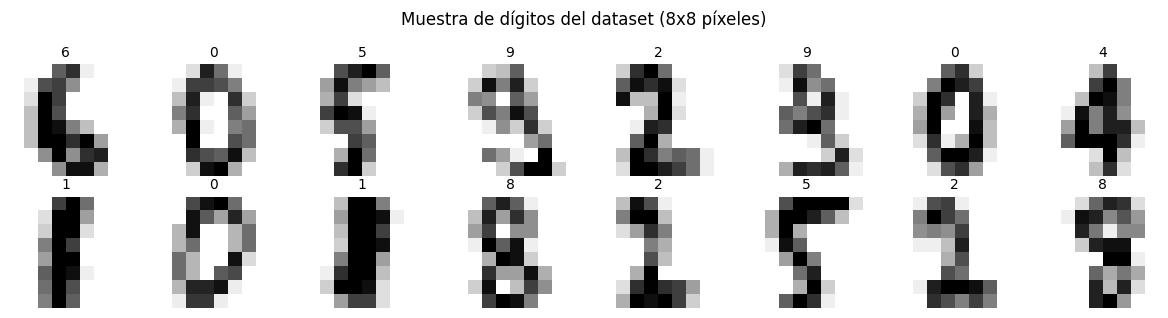

In [36]:
# Guardar una muestra de dígitos para el documento
fig, axes = plt.subplots(2, 8, figsize=(12,3.2))
rng  = np.random.RandomState(7)
idxs = rng.choice(len(X_img),16,replace=False)
for ax, idx in zip(axes.ravel(), idxs):
    ax.imshow(X_img[idx].reshape(8,8),cmap='gray_r')
    ax.set_title(str(y[idx]),fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra de dígitos del dataset (8x8 píxeles)")
plt.tight_layout()
plt.savefig('assets/sample_digits.png',dpi=150)
plt.show()
plt.close()

results = {}

### Secuencia modelo baseline

<div align="center">

**Imagen**  
8 × 8 × 1  
↓  
**Conv2D**  
8 × 8 × 32  
↓  
**MaxPooling**  
4 × 4 × 32  
↓  
**Flatten**  
512 valores unidimensionales  
↓  
**Dense**  
64 neuronas  
↓  
**Dense**  
10 neuronas (10 clases)

</div>

In [37]:
#&&&&&&&&&&&&&&&    Modelo baseline   &&&&&&&&&&&&&&&
#------- sin regularización, hiperparametros simples -------
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(8,8,1)),              #==> capa de entrada
        #                   │ │ └─── 1 canal -> escala de grises 
        #                   │ └─── ancho 8 píxeles
        #                   └─── alto  8 píxeles
        layers.Conv2D(                            #==> capa de convolución 2D
                     32,     #cantidad de filtro
                     kernel_size=3,# tamaño del filtro 3x3
                     padding='same', # mantiene el tamaño espacial de la salida en 8x8 (en vez de dejar en 6x6)
                     activation='relu'), # función de activación
        #Salida de las conv2dD es de 8 × 8 × 32

        layers.MaxPooling2D(pool_size=2),         #==> capa de agrupamiento, tipo maxpooling
        #Salida de Maxpoolin2d es de 4 × 4 × 32
        # toma regiones de 2×2 píxeles y se queda solamente con el valor máximo de cada regió
        layers.Flatten(),                         #==> convierte el mapa de caracteristica aun vector unidimensional
        layers.Dense(64,activation='relu'),       #==> Capa densa 
        #             |    └─ función de activación tipo ReLu
        #             └─ con 64 neuronas 
        layers.Dense(10,activation='softmax')     #==> Capa de salida densa 
        #             |    └─ función de activación tipo Softmax
        #             └─ 10 neuronas porque son 10 clases 
    ], name="CNN_baseline")
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy', #y es int
                  metrics=['accuracy'])
    return model

baseline = build_baseline()
baseline.summary()

hist_base = baseline.fit(
    X_train, y_train,
    validation_split=0.2, # 20% de validación 
    epochs=25,            # epocas 
    batch_size=32,        # procesa los datos en grupos de 32 registro
    verbose=2             # conf. de info que muestra keras, 0 -> no muestra info
)

test_loss_b, test_acc_b = baseline.evaluate(X_test,y_test,verbose=0)
y_pred_b = np.argmax(baseline.predict(X_test,verbose=0),axis=1)
cm_b = confusion_matrix(y_test,y_pred_b)

results['baseline'] = {
    'test_loss' : float(test_loss_b),
    'test_acc'  : float(test_acc_b),
    'epochs_run': len(hist_base.history['loss']),
    'final_train_acc': float(hist_base.history['accuracy'][-1]),
    'final_val_acc'  : float(hist_base.history['val_accuracy'][-1]),
    'params': baseline.count_params()
}

Model: "CNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,802 (132.04 KB)

 Trainable params: 33,802 (132.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
36/36 - 1s - 42ms/step - accuracy: 0.1610 - loss: 2.2844 - val_accuracy: 0.1944 - val_loss: 2.2761
Epoch 2/25
36/36 - 1s - 25ms/step - accuracy: 0.2254 - loss: 2.2589 - val_accuracy: 0.2361 - val_loss: 2.2546
Epoch 3/25
36/36 - 0s - 8ms/step - accuracy: 0.2742 - loss: 2.2338 - val_accuracy: 0.2639 - val_loss: 2.2312
Epoch 4/25
36/36 - 0s - 7ms/step - accuracy: 0.3438 - loss: 2.2064 - val_accuracy: 0.3056 - val_loss: 2.2056
Epoch 5/25
36/36 - 0s - 7ms/step - accuracy: 0.4073 - loss: 2.1757 - val_accuracy: 0.3646 - val_loss: 2.1757
Epoch 6/25
36/36 - 0s - 8ms/step - accuracy: 0.4674 - loss: 2.1398 - val_accuracy: 0.4444 - val_loss: 2.1397
Epoch 7/25
36/36 - 0s - 7ms/step - accuracy: 0.5361 - loss: 2.0967 - val_accuracy: 0.5000 - val_loss: 2.0957
Epoch 8/25
36/36 - 0s - 7ms/step - accuracy: 0.5796 - loss: 2.0451 - val_accuracy: 0.5486 - val_loss: 2.0425
Epoch 9/25
36/36 - 0s - 7ms/step - accuracy: 0.6179 - loss: 1.9834 - val_accuracy: 0.6076 - val_loss: 1.9784
Epoch 10/25
36/36

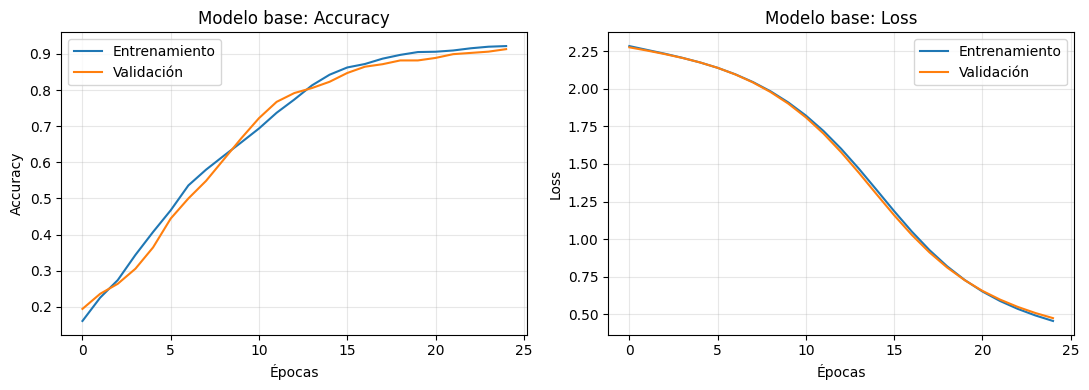

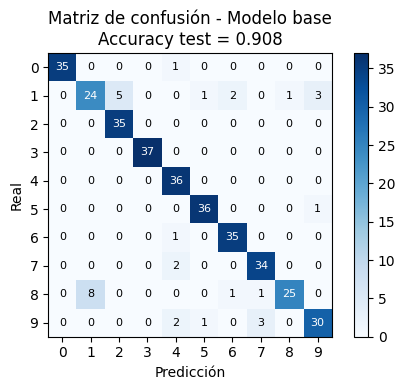

In [38]:
#&&&&&  Plot curvas baseline &&&&& 
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(hist_base.history['accuracy'],label='Entrenamiento')
axes[0].plot(hist_base.history['val_accuracy'],label='Validación')
axes[0].set_title('Modelo base: Accuracy')
axes[0].set_xlabel('Épocas'); axes[0].set_ylabel('Accuracy');axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_base.history['loss'],label='Entrenamiento')
axes[1].plot(hist_base.history['val_loss'],label='Validación')
axes[1].set_title('Modelo base: Loss')
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('Loss');axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/baseline_curves.png',dpi=150)
plt.show()
plt.close()

#&&&&&   Matriz de confusión baseline   &&&&& 
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_b, cmap='Blues')
ax.set_title(f'Matriz de confusión - Modelo base\nAccuracy test = {test_acc_b:.3f}')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j,i,cm_b[i,j], ha='center',va='center',
                color='white' if cm_b[i,j] > cm_b.max()/2 else 'black',fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('assets/baseline_confmat.png', dpi=150)
plt.show()
plt.close()


De la curva de accuracy se ve que en las primeras épocas (6 a 10) el modelo mejora muy rápido, esto se debe a que la red recién está aprendiendo a distinguir las clases más básicas.En cambio al final del entrenamiento
entrenamiento (épocas 21 a 25), esos saltos se reducen lo que indica que el modelo se está acercando a su límite de aprendizaje con esta 
arquitectura y este optimizador (SGD, learning rate=0.01).
De la curva de loss se ve que está deciende con fuerza al principio y su descenso se vuelve cada vez más gradual hacia el final. 
El modelo no llega a aplanarse por completo, todavía hay una leve mejora en la última época. La convergencia podría ser mas rápida si se usa Adam

de la matriz de confusión se ve que el desempeño es desigual entre dígitos. Las clases que mejor se reconoce son:
- el 0 (f1=0.986)
- el 5 (f1=0.961) 
-y el 2 (f1=0.958). 
Por otro lado, el dígito 1 es el más difícil para mi modelo (f1=0.743) seguido de cerca por el 8 y el 9 (f1=0.806 en ambos casos).

Cabe destacar que, note el patrón específico detrás de estos dos últimos: tanto el 8 como el 9 tienen precisión relativamente alta (0.926 y 0.871) pero recall más bajo 0.714 y 0.750 respectivamente, es decir, cuando mi modelo predice "8" o "9" generalmente acierta, pero se le escapa una porción importante de los 8 y 9 reales, que termina clasificando como otro dígito. Esto implica que mi modelo baseline, aun con 25 épocas de entrenamiento, todavía no logra capturar del todo los rasgos que distinguen a estos dos dígitos en imágenes de tan baja resolución (8×8 píxeles).

### Secuencia modelo optimizado

<div align="center">

**Imagen**  
8 × 8 × 1  
↓  
**Conv2D**  
8 × 8 × 32  
↓  
**MaxPooling**  
4 × 4 × 32  
↓  
**Dropout (25%)**  
4 × 4 × 32  
↓  
**Flatten**  
512 valores unidimensionales  
↓  
**Dense**  
128 neuronas  
↓  
**Dropout (50%)**  
128 neuronas  
↓  
**Dense**  
10 neuronas (10 clases)

</div>

Model: "CNN_optimizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,274 (262.79 KB)

 Trainable params: 67,274 (262.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 - 2s - 113ms/step - accuracy: 0.2324 - loss: 2.2115 - val_accuracy: 0.6181 - val_loss: 2.0587
Epoch 2/50
18/18 - 0s - 14ms/step - accuracy: 0.4630 - loss: 1.9183 - val_accuracy: 0.8576 - val_loss: 1.6308
Epoch 3/50
18/18 - 0s - 12ms/step - accuracy: 0.6275 - loss: 1.5007 - val_accuracy: 0.8542 - val_loss: 1.1366
Epoch 4/50
18/18 - 0s - 12ms/step - accuracy: 0.7250 - loss: 1.0818 - val_accuracy: 0.8924 - val_loss: 0.7426
Epoch 5/50
18/18 - 0s - 12ms/step - accuracy: 0.8007 - loss: 0.7760 - val_accuracy: 0.8854 - val_loss: 0.5322
Epoch 6/50
18/18 - 0s - 13ms/step - accuracy: 0.8320 - loss: 0.6311 - val_accuracy: 0.9028 - val_loss: 0.4197
Epoch 7/50
18/18 - 0s - 12ms/step - accuracy: 0.8538 - loss: 0.5159 - val_accuracy: 0.8993 - val_loss: 0.3459
Epoch 8/50
18/18 - 0s - 19ms/step - accuracy: 0.8816 - loss: 0.4566 - val_accuracy: 0.9444 - val_loss: 0.2920
Epoch 9/50
18/18 - 0s - 14ms/step - accuracy: 0.8869 - loss: 0.4022 - val_accuracy: 0.9410 - val_loss: 0.2598
Epoch 10/

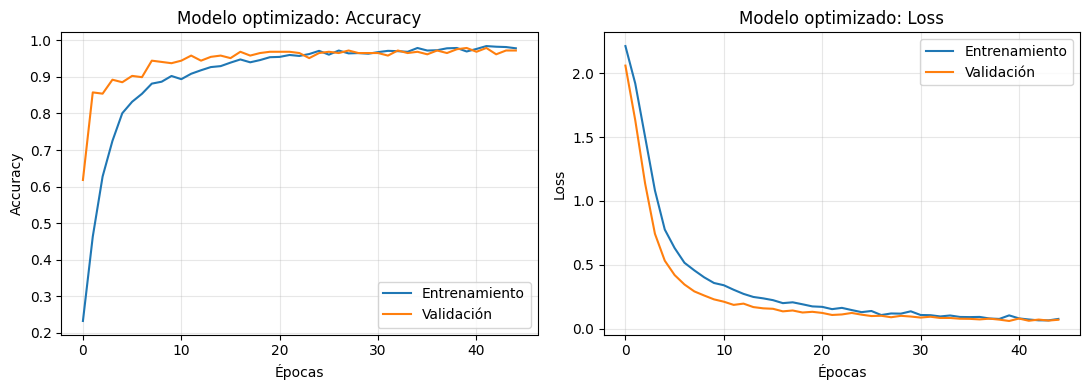

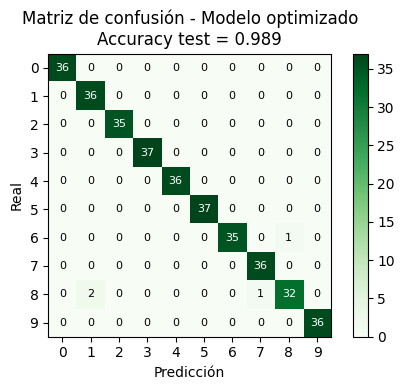

In [39]:
#&&&&&&&&&&&&&&&    Modelo Optimizado   &&&&&&&&&&&&&&&
#&&&&& Dropout + EarlyStopping + nuevos hiperparametros
def build_improved():
    model = keras.Sequential([
        layers.Input(shape=(8,8,1)),                       #==> capa de entrada
        layers.Conv2D(32,kernel_size=3,                    #==> Capa de convolución 2D
                      padding='same',activation='relu'),
        layers.MaxPooling2D(pool_size=2),                  #==> capa de agrupamiento
        layers.Dropout(0.25),                     # Regularización
        layers.Flatten(),                                  #==> capa de aplanamiento  
        layers.Dense(128,activation='relu'),               #==> capa densa 
        layers.Dropout(0.5),                      # Regularización
        layers.Dense(10,activation='softmax')              #==> capa densa de salida 
    ], name="CNN_optimizado")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

improved = build_improved()
improved.summary()

#detiene el entrenamiento cuando el modelo deja de mejorar
early_stop = keras.callbacks.EarlyStopping(
    monitor ='val_loss', 
    patience=5,           # esperar 5 epocas consecutivas sin mejora antes de detener el entrenamiento
    restore_best_weights=True # recupera los pesos de la época donde se obtuvo el menor val_loss
)

hist_imp = improved.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop], 
    verbose=2
)

test_loss_i, test_acc_i = improved.evaluate(X_test, y_test, verbose=0)
y_pred_i = np.argmax(improved.predict(X_test, verbose=0), axis=1)
cm_i = confusion_matrix(y_test, y_pred_i)

results['improved'] = {
    'test_loss' : float(test_loss_i),
    'test_acc'  : float(test_acc_i),
    'epochs_run': len(hist_imp.history['loss']),
    'final_train_acc': float(hist_imp.history['accuracy'][-1]),
    'final_val_acc'  : float(hist_imp.history['val_accuracy'][-1]),
    'params': improved.count_params()
}

#&&&&&  Plot curvas improved  &&&&& 
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(hist_imp.history['accuracy'], label='Entrenamiento')
axes[0].plot(hist_imp.history['val_accuracy'], label='Validación')
axes[0].set_title('Modelo optimizado: Accuracy')
axes[0].set_xlabel('Épocas'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_imp.history['loss'], label='Entrenamiento')
axes[1].plot(hist_imp.history['val_loss'], label='Validación')
axes[1].set_title('Modelo optimizado: Loss')
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/improved_curves.png', dpi=150)
plt.show()
plt.close()

#&&&&&  Matriz de confusion improved   &&&&& 
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_i, cmap='Greens')
ax.set_title(f'Matriz de confusión - Modelo optimizado\nAccuracy test = {test_acc_i:.3f}')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_i[i,j], ha='center', va='center',
                color='white' if cm_i[i,j] > cm_i.max()/2 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('assets/improved_confmat.png', dpi=150)
plt.show()
plt.close()

La curva del modelo optimizado muestra un ascenso mas rápido en las primeras 10  épocas esto se debe al optimizador Adam, alcanza en la época 5 un 90.3% de accuracy de validación lo que a baseline le tomó 25 épocas completas llegar a superar. 
A partir de la época 20 aproximadamente, la curva se vuelve más ruidosa, 
oscilando levemente de época en época, pero mantiene una tendencia de fondo hacia un loss cada vez más bajo: el mínimo de todo el entrenamiento se alcanza recién en la última época (val_loss=0.060), lo que indica que el modelo aún tenía margen para seguir mejorando levemente, aunque a un ritmo mucho más lento que al inicio. La  brecha entre accuracy de entrenamiento de 99.1% y de validación de 96.9% es pequeña, lo que indica un leve sobreajuste que el Dropout logra mantener acotado.

De la matriz de confusión del modelo optimizado, se ve que casi es diagonal por completo, en 6 de las 10 clases se logró un f1-score de 0.986 o superior. 
El único punto débil que me queda es el dígito 8 (f1=0.941, recall=0.914) la misma clase que ya me había dado más problemas en el baseline. Sin embargo, al comparar es posible ver el efecto directo de cada mejora que apliqué:
- el recall del dígito 8 pasó de 0.343 en mi modelo baseline con 15 épocas, a 0.714 al extenderlo a 25 épocas, y finalmente a 0.914 con mi modelo optimizado completo (Adam + Dropout + EarlyStopping). 
- El dígito 1, que en mi modelo baseline era, junto al 8, la clase más 
débil (f1 entre 0.641 y 0.743 según la corrida), quedo casi bien con el modelo optimizado (f1=0.973). 

Esto conlleva no eran una limitación del dataset en sí, sino del optimizador y la falta de regularización que usé al principio en el baseline.

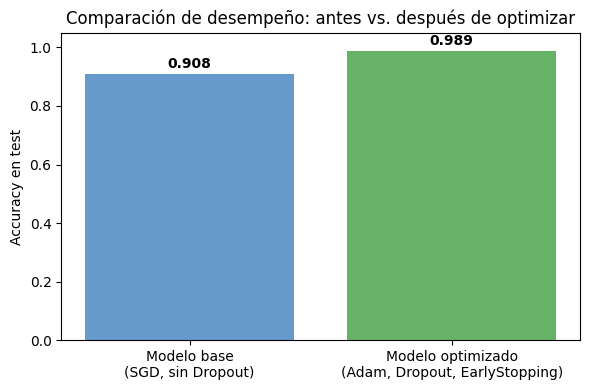

{
  "baseline": {
    "test_loss": 0.4671793282032013,
    "test_acc": 0.9083333611488342,
    "epochs_run": 25,
    "final_train_acc": 0.9216710329055786,
    "final_val_acc": 0.9131944179534912,
    "params": 33802
  },
  "improved": {
    "test_loss": 0.05215334892272949,
    "test_acc": 0.9888888597488403,
    "epochs_run": 45,
    "final_train_acc": 0.9782419204711914,
    "final_val_acc": 0.9722222089767456,
    "params": 67274
  }
}

Classification report - baseline:
               precision    recall  f1-score   support

           0      1.000     0.972     0.986        36
           1      0.750     0.667     0.706        36
           2      0.875     1.000     0.933        35
           3      1.000     1.000     1.000        37
           4      0.857     1.000     0.923        36
           5      0.947     0.973     0.960        37
           6      0.921     0.972     0.946        36
           7      0.895     0.944     0.919        36
           8      0.962     0.714

In [40]:
#&&&&&&&&&&&&&&&    Comparación final   &&&&&&&&&&&&&&&    
fig, ax = plt.subplots(figsize=(6,4))
labels = ['Modelo base\n(SGD, sin Dropout)', 'Modelo optimizado\n(Adam, Dropout, EarlyStopping)']
accs = [test_acc_b, test_acc_i]
bars = ax.bar(labels, accs, color=['#6699CC', '#66B266'])
ax.set_ylabel('Accuracy en test')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de desempeño: antes vs. después de optimizar')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, acc+0.02, f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/comparison_bar.png', dpi=150)
plt.show()
plt.close()

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print("\nClassification report - baseline:\n", classification_report(y_test, y_pred_b, digits=3))
print("\nClassification report - improved:\n", classification_report(y_test, y_pred_i, digits=3))